### Combined Code for LightGBM Classification Model

Dữ liệu đã được tải:


,term,subGrade,annualIncome,verificationStatus,isDefault,dti,ficoRangeLow,ficoRangeHigh,revolUtil,issueDate_months,debtpca1-1,npca1-1,npca1-2,netprofit
0,5,E2,110000.0,2.0,1.0,17.05,730.0,734.0,48.9,84.001314,3.320686,-0.880843,-0.959011,91245.0
1,5,D2,46000.0,2.0,0.0,27.83,700.0,704.0,38.9,61.038108,0.495487,0.016687,-0.061481,33198.2
2,5,D3,74000.0,2.0,0.0,22.77,675.0,679.0,51.8,99.014455,-0.509851,0.407173,-1.648674,57150.2
3,3,A4,35000.0,0.0,0.0,17.49,755.0,759.0,8.5,87.023653,-2.066271,-0.087247,-1.154255,28878.5
4,3,C3,30000.0,2.0,0.0,32.60,665.0,669.0,59.7,78.055191,-0.255045,-0.282490,-0.360658,20220.0



Thông tin DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271698 entries, 0 to 271697
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   term                271698 non-null  int64  
 1   subGrade            271698 non-null  object 
 2   annualIncome        271698 non-null  float64
 3   verificationStatus  271698 non-null  float64
 4   isDefault           271698 non-null  float64
 5   dti                 271698 non-null  float64
 6   ficoRangeLow        271697 non-null  float64
 7   ficoRangeHigh       271696 non-null  float64
 8   revolUtil           271696 non-null  float64
 9   issueDate_months    271695 non-null  float64
 10  debtpca1-1          271695 non-null  float64
 11  npca1-1             271694 non-null  float64
 12  npca1-2             271694 non-null  float64
 13  netprofit           271693 non-null  float64
dtypes: float64(12), int64(1), object(1)
memory usage: 29.0+ MB


None


Kích thước tập huấn luyện X: (217354, 13)
Kích thước tập kiểm tra X: (54339, 13)
Kích thước tập huấn luyện Y: (217354,)
Kích thước tập kiểm tra Y: (54339,)

Bắt đầu huấn luyện mô hình LightGBM...
[LightGBM] [Info] Number of positive: 41855, number of negative: 175499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1685
[LightGBM] [Info] Number of data points in the train set: 217354, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.192566 -> initscore=-1.433422
[LightGBM] [Info] Start training from score -1.433422
Mô hình LightGBM đã được huấn luyện thành công.

Đánh giá mô hình:
Accuracy: 0.8103
Precision: 0.5732
Recall: 0.0588
AUC: 0.7217


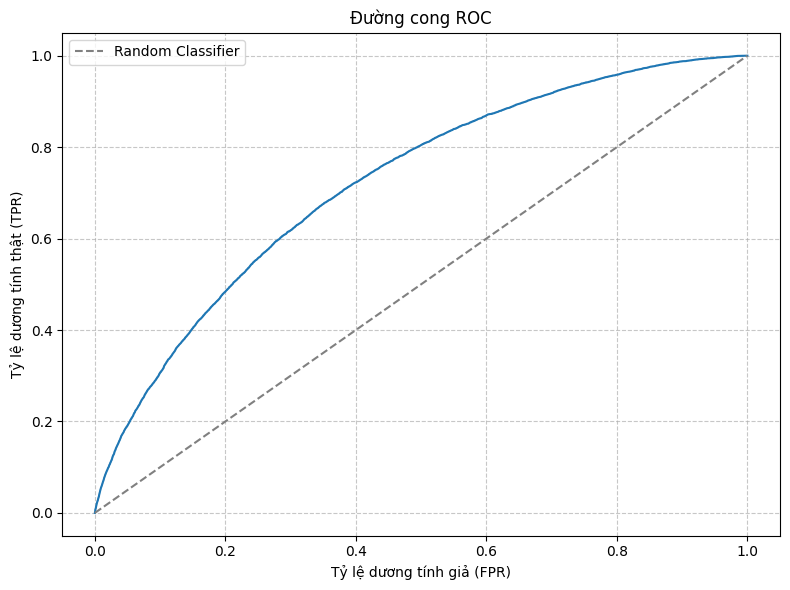

In [10]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('/content/PJ2008.csv', on_bad_lines='skip')
print("Dữ liệu đã được tải:")
display(df.head())

# 2. Data Preparation
print("\nThông tin DataFrame:")
display(df.info())

# Drop rows with any missing values for simplicity
df.dropna(inplace=True)

# Define target variable (Y) and features (X)
Y = df['isDefault']
X = df.drop(columns=['isDefault'])

# Identify categorical features and apply Label Encoding
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"\nKích thước tập huấn luyện X: {X_train.shape}")
print(f"Kích thước tập kiểm tra X: {X_test.shape}")
print(f"Kích thước tập huấn luyện Y: {Y_train.shape}")
print(f"Kích thước tập kiểm tra Y: {Y_test.shape}")

# 3. LightGBM Model Training
print("\nBắt đầu huấn luyện mô hình LightGBM...")
lgbm = lgb.LGBMClassifier(objective='binary', metric='auc', random_state=42)
lgbm.fit(X_train, Y_train)
print("Mô hình LightGBM đã được huấn luyện thành công.")

# 4. Model Evaluation
print("\nĐánh giá mô hình:")
# Make predictions on the test set
Y_pred = lgbm.predict(X_test)
Y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
auc = roc_auc_score(Y_test, Y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC: {auc:.4f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)
sns.lineplot(x=fpr, y=tpr, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
ax.set_title('Đường cong ROC')
ax.set_xlabel('Tỷ lệ dương tính giả (FPR)')
ax.set_ylabel('Tỷ lệ dương tính thật (TPR)')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()